In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
import pickle
import sbi.utils as utils
import torch
from seaborn import histplot, kdeplot, boxplot, violinplot
from time import time
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import wrapper
from evo_sim import evo_sim, EVO_SIM_wrapper, plot_vec30
from inference_utils import get_prior
import warnings
warnings.simplefilter('ignore', FutureWarning)


def EVO_SIM_wrapper(reps, parameters, seed=None):
    evo_reps = torch.empty(reps, 30)
    for i in range(reps):
        out=evo_sim(parameters)
        evo_reps[i,:] = torch.tensor(out)
    return evo_reps

# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

posterior = pickle.load(open('posterior_EVO_SIM_30000_20.pkl', 'rb'))
prior = get_prior('EVO_SIM')
prior.base_dist.low, prior.base_dist.high

(tensor([-3., -3., -3., -8., -8., -8.]),
 tensor([-1., -1., -1., -4., -4., -4.]))

Text(0.5, 0.01, '$log(\\theta^{est} / \\theta^{true})$')

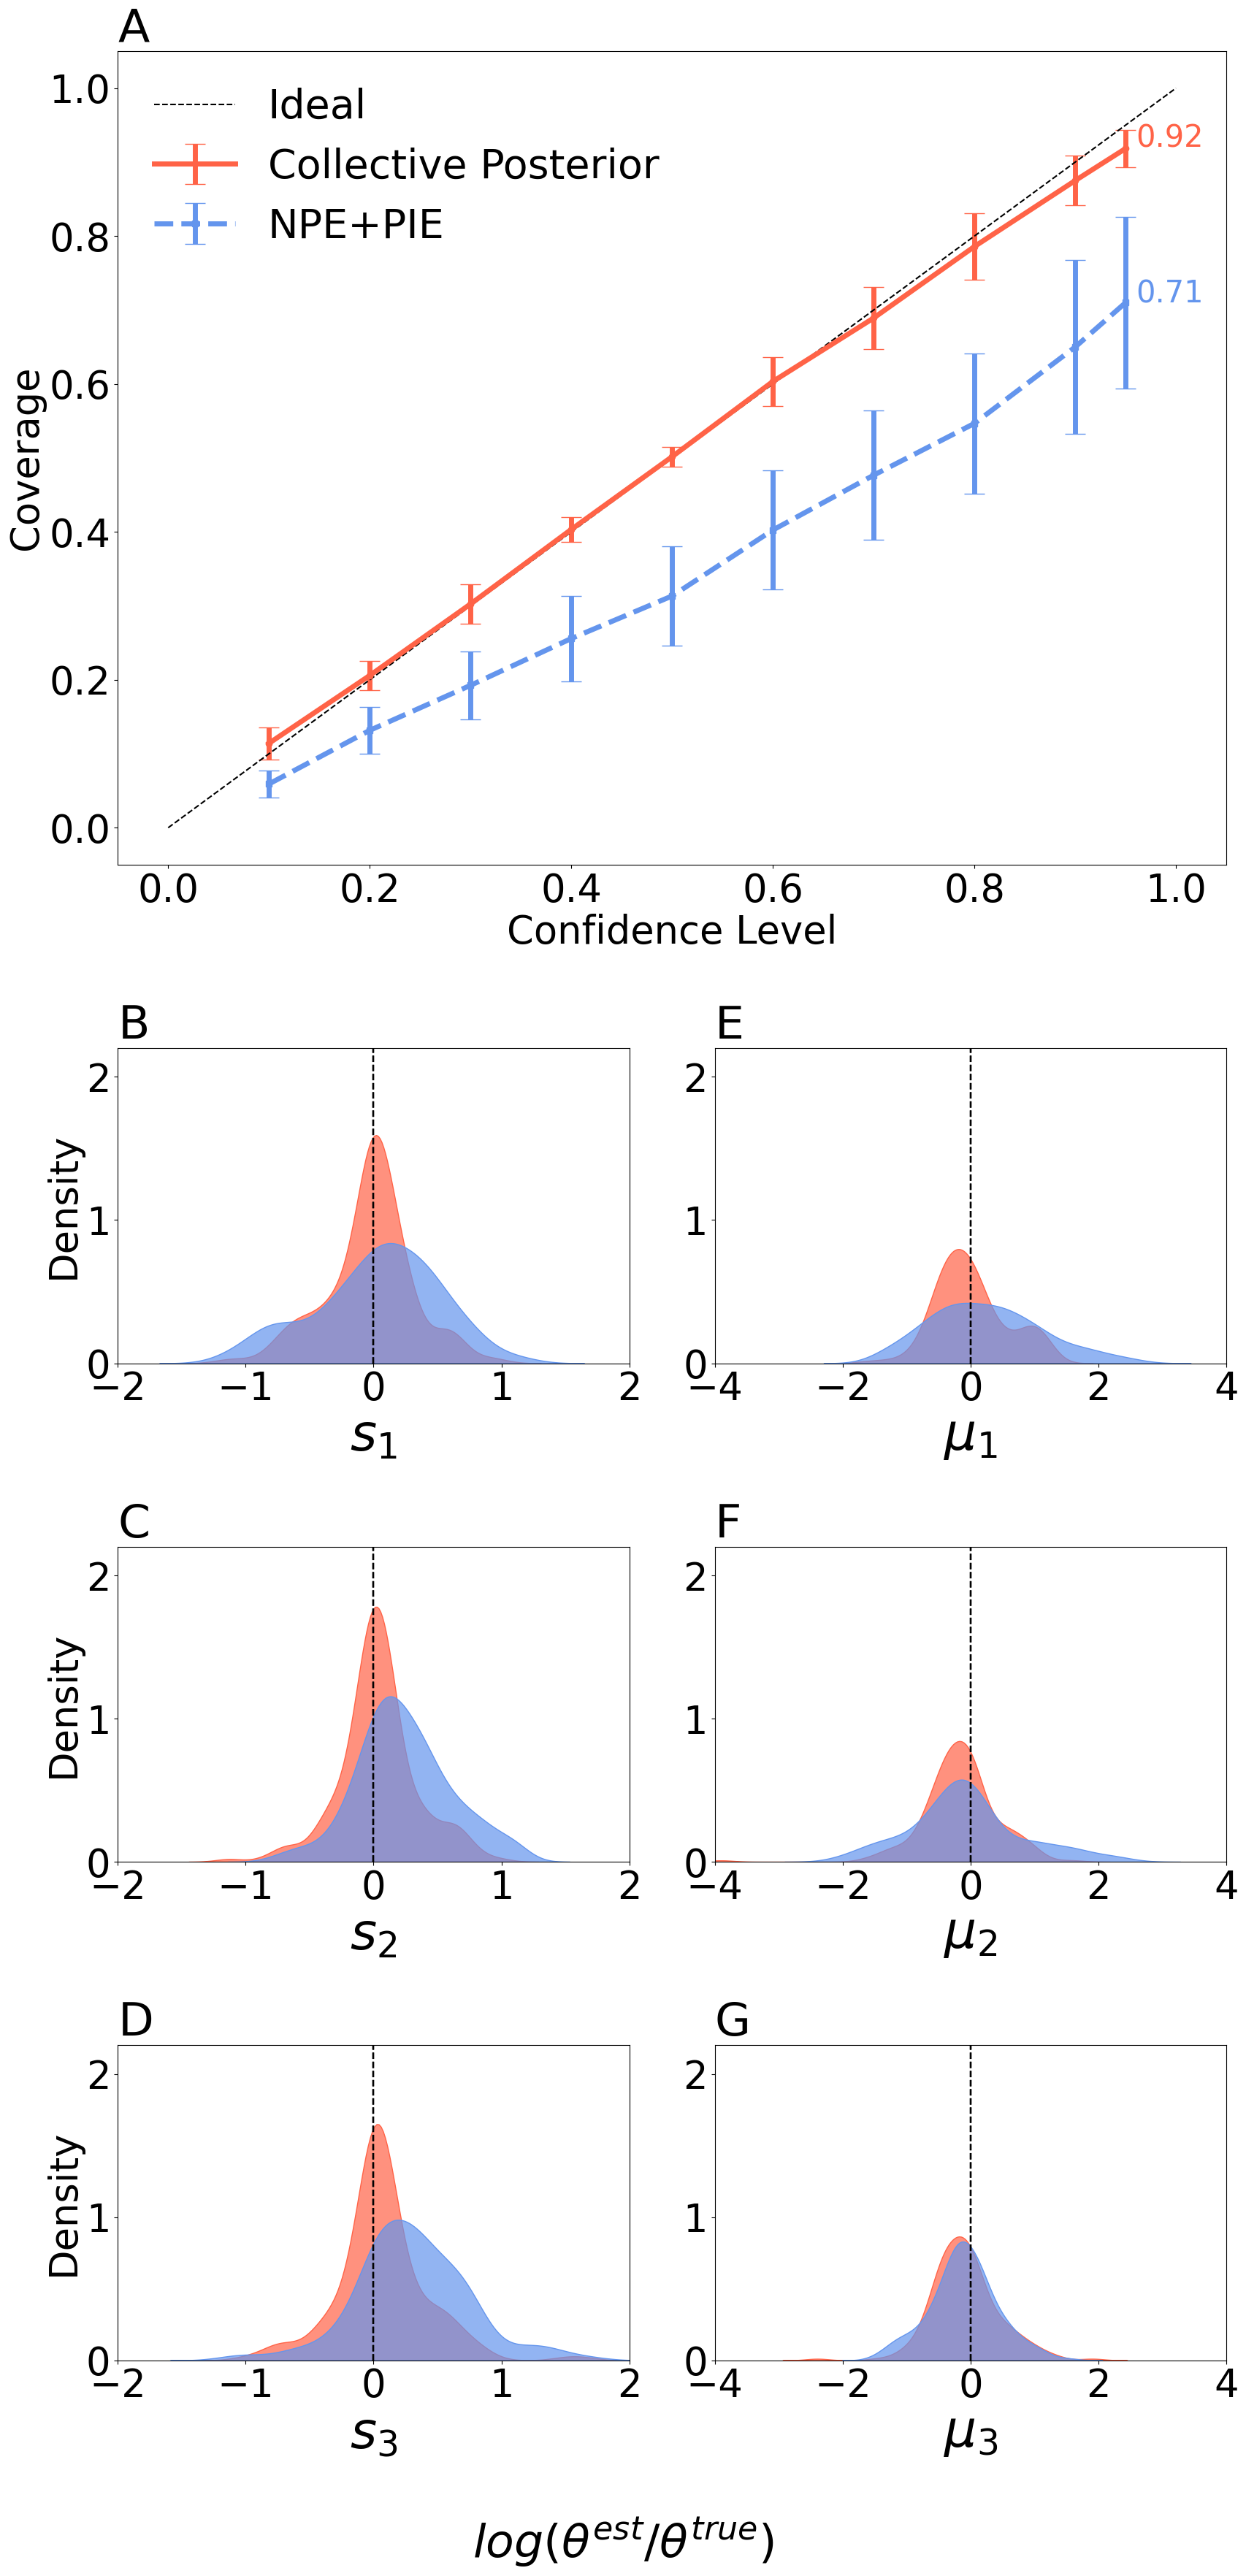

In [42]:
change_font(38)

# plot accuracy in 2X3 axis
def plot_accuracy(acc, ax, color, label, hatch):
    parameters = ['$s_1$', '$s_2$', '$s_3$', '$\\mu_1$', '$\\mu_2$', '$\\mu_3$']
    for i in range(len(ax)):

        kdeplot(acc[:,i],ax=ax[i], color=color, alpha=0.7, fill=True)
        ax[i].axvline(0, color='k', lw=1.7, ls='--')
        ax[i].set_xlabel(parameters[i], fontsize=50)
        max_error = prior.base_dist.high[i] - prior.base_dist.low[i]
        ax[i].set_xlim(-1*max_error,max_error)
        ax[i].set_ylim(0,2.2)
    return

conf_levels = np.array([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95], dtype=float)
def plot_covs(ax, covs1, covs2, conf_levels=conf_levels):
    """
    Plot mean coverage across parameters (and repeats) with error bars showing
    variability among parameters.

    Expects covs arrays of shape (n_repeats, n_conf, n_params) or (n_conf, n_params).
    """
    import numpy as np

    def to_np(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    a1 = to_np(covs1)
    a2 = to_np(covs2)

    # normalize shapes to (n_repeats, n_conf, n_params)
    if a1.ndim == 2:
        a1 = a1[None, ...]
    if a2.ndim == 2:
        a2 = a2[None, ...]

    n_reps, n_conf, n_params = a1.shape

    # For each confidence level, compute per-parameter mean across repeats,
    # then compute the mean across parameters (value to plot) and the std across parameters
    mean1 = np.empty(n_conf)
    sd1 = np.empty(n_conf)
    mean2 = np.empty(n_conf)
    sd2 = np.empty(n_conf)

    for j in range(n_conf):
        # shape (n_reps, n_params) -> mean over repeats -> (n_params,)
        per_param_mean1 = a1[:, j, :].mean(axis=0)
        per_param_mean2 = a2[:, j, :].mean(axis=0)
        # mean across parameters
        mean1[j] = per_param_mean1.mean()
        mean2[j] = per_param_mean2.mean()
        # variability among parameters (std). Use std (not se) as requested.
        sd1[j] = per_param_mean1.std(ddof=0)
        sd2[j] = per_param_mean2.std(ddof=0)

    palette = {'Collective Posterior': 'tomato', 'NPE+PIE': 'cornflowerblue'}

    ax.errorbar(conf_levels, mean1, yerr=sd1, label='Collective Posterior',
                color=palette['Collective Posterior'], marker='o', linestyle='-', capsize=10, linewidth=5)
    ax.errorbar(conf_levels, mean2, yerr=sd2, label='NPE+PIE',
                color=palette['NPE+PIE'], marker='s', linestyle='--', capsize=10, linewidth=5)
    ax.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), color='k', linestyle='--', label='Ideal')
    final_cov_1 = int(100*round(covs1.mean(0)[-1].mean().item(),2))/100
    final_cov_2 = int(100*round(covs2.mean(0)[-1].mean().item(),2))/100
    ax.annotate(f'{final_cov_1}', xy=(conf_levels[-1]+0.01, final_cov_1), xytext=(conf_levels[-1]+0.01, final_cov_1),
                fontsize=30, color='tomato')
    ax.annotate(f'{final_cov_2}', xy=(conf_levels[-1]+0.01, final_cov_2), xytext=(conf_levels[-1]+0.01, final_cov_2),
                fontsize=30, color='cornflowerblue')
    ax.legend(fontsize=40, frameon=False)


# A - Coverage plots
# B-D - Accuracy plots
mosaic = '''AA
            AA
            BE
            CF
            DG
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,36), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')
ax['E'].set_title('E',loc='left')
ax['F'].set_title('F',loc='left')
ax['G'].set_title('G',loc='left')

# Coverage plots in ax B
covs = torch.load(f'covs_EVO_SIM_r_imp.pt')
covs_iid = torch.load(f'covs_EVO_SIM_iid_r.pt')
plot_covs(ax=ax['A'], covs1=covs.numpy(), covs2=covs_iid.numpy())
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
# Accuracy plots in ax C-E
n_params=6


axx = [ax['B'], ax['C'], ax['D'], ax['E'], ax['F'], ax['G']]

cp_acc = torch.load('accus_EVO_SIM_r_imp.pt')
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')
    
iid_acc = torch.load('accus_EVO_SIM_iid_r.pt')
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['E'].set_ylabel('')
ax['F'].set_ylabel('')
ax['G'].set_ylabel('')
fig.supxlabel('$log(\\theta^{est} / \\theta^{true})$')


Text(0, 0.5, '')

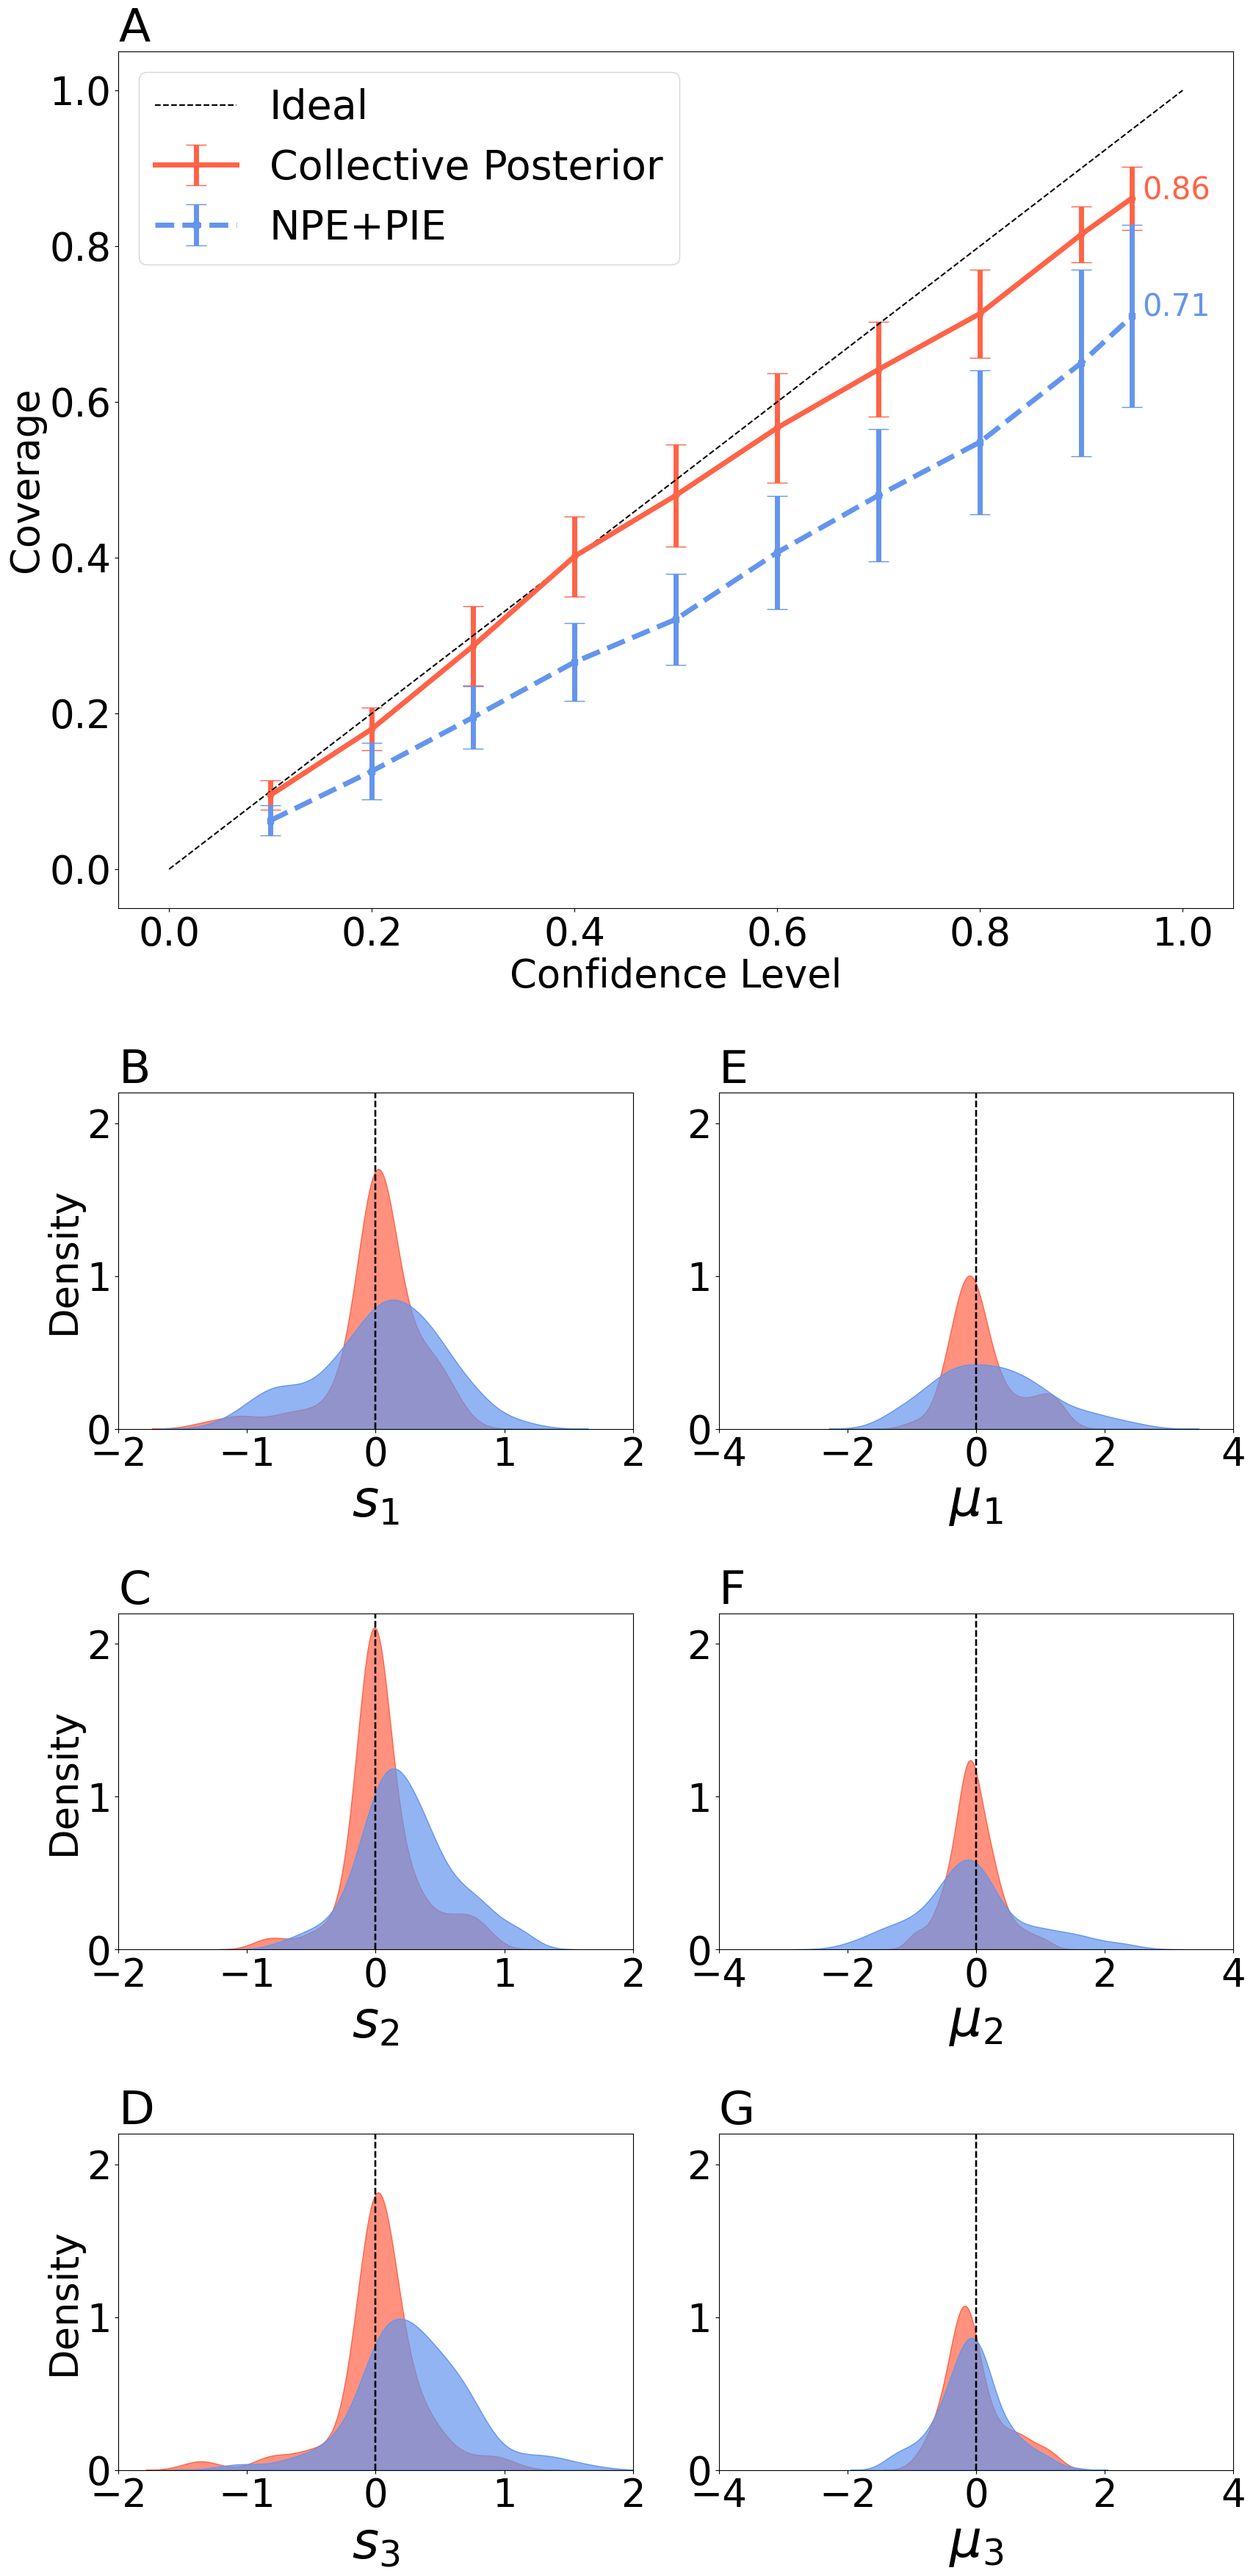

In [37]:
mosaic = '''AA
            AA
            BE
            CF
            DG
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,36), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')
ax['E'].set_title('E',loc='left')
ax['F'].set_title('F',loc='left')
ax['G'].set_title('G',loc='left')
# Coverage plots in ax B
covs = torch.load(f'covs_EVO_SIM_h.pt')
covs_iid = torch.load(f'covs_EVO_SIM_iid_h.pt')
plot_covs(ax=ax['A'], covs1=covs, covs2=covs_iid)
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
ax['A'].legend(fontsize=40)
# Accuracy plots in ax C-E
n_params=6


axx = [ax['B'], ax['C'], ax['D'], ax['E'], ax['F'], ax['G']]

cp_acc = torch.load('accus_EVO_SIM_h.pt')
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = torch.load('accus_EVO_SIM_iid_h.pt')
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['E'].set_ylabel('')
ax['F'].set_ylabel('')
ax['G'].set_ylabel('')


Text(0, 0.5, '')

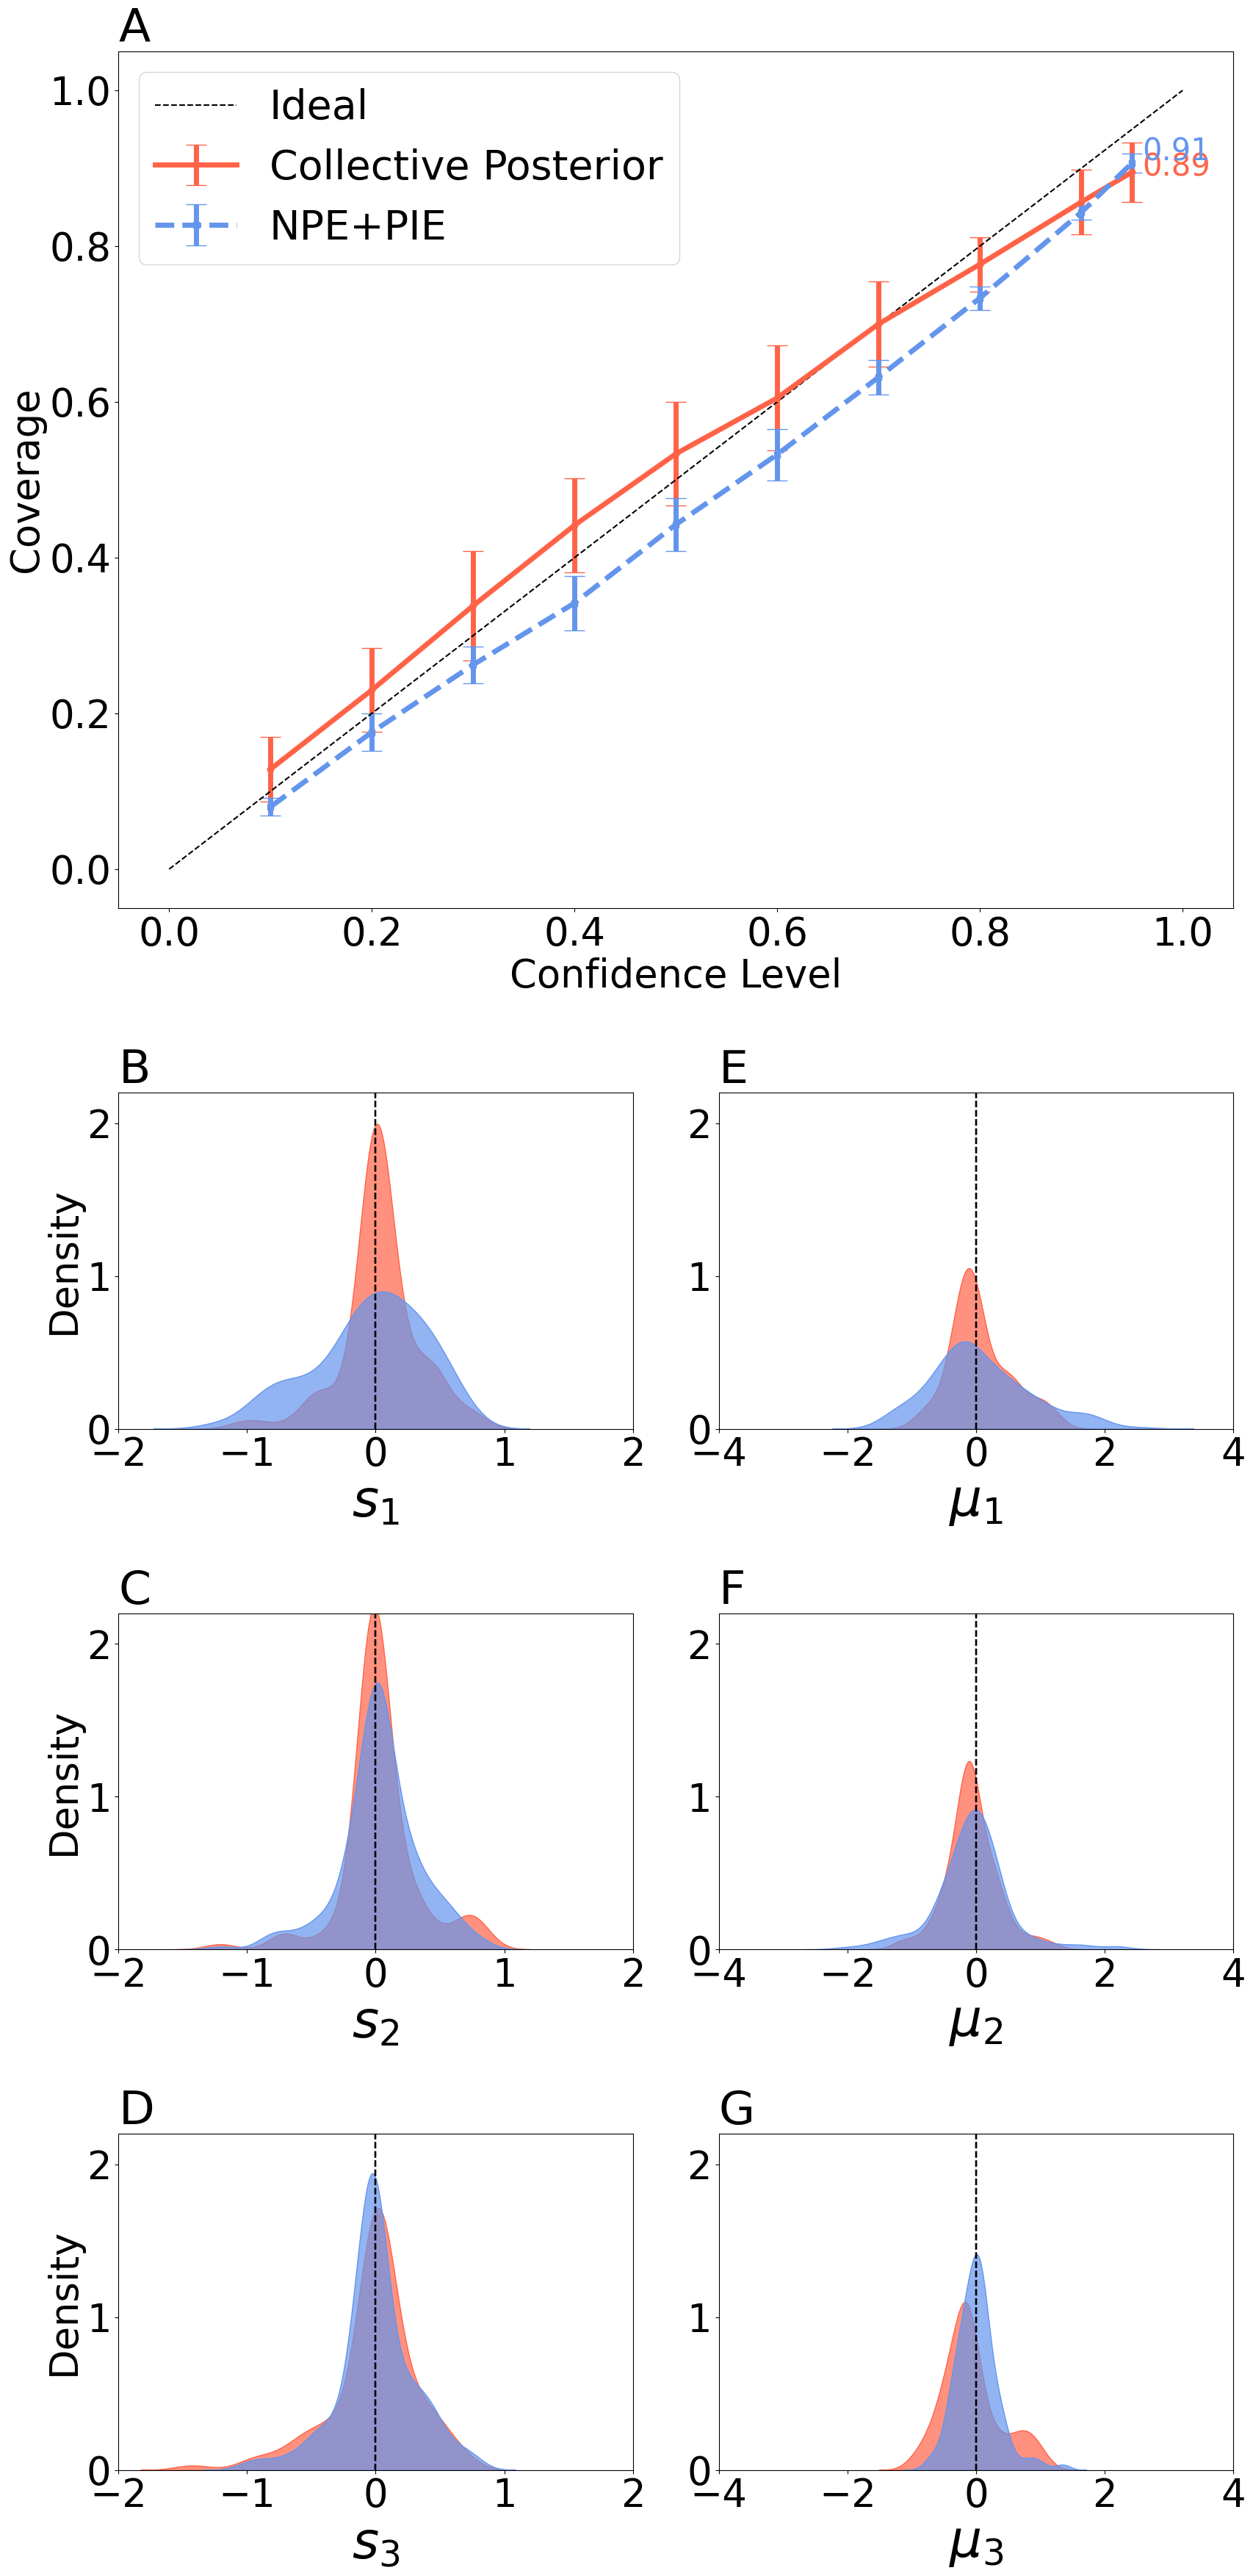

In [36]:
mosaic = '''AA
            AA
            BE
            CF
            DG
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,36), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')
ax['E'].set_title('E',loc='left')
ax['F'].set_title('F',loc='left')
ax['G'].set_title('G',loc='left')
# Coverage plots in ax B
covs = torch.load(f'covs_EVO_SIM.pt')
covs_iid = torch.load(f'covs_EVO_SIM_iid.pt')
plot_covs(ax=ax['A'], covs1=covs, covs2=covs_iid)
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
ax['A'].legend(fontsize=40)
# Accuracy plots in ax C-E
n_params=6


axx = [ax['B'], ax['C'], ax['D'], ax['E'], ax['F'], ax['G']]

cp_acc = torch.load('accus_EVO_SIM.pt')
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = torch.load('accus_EVO_SIM_iid.pt')
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['E'].set_ylabel('')
ax['F'].set_ylabel('')
ax['G'].set_ylabel('')


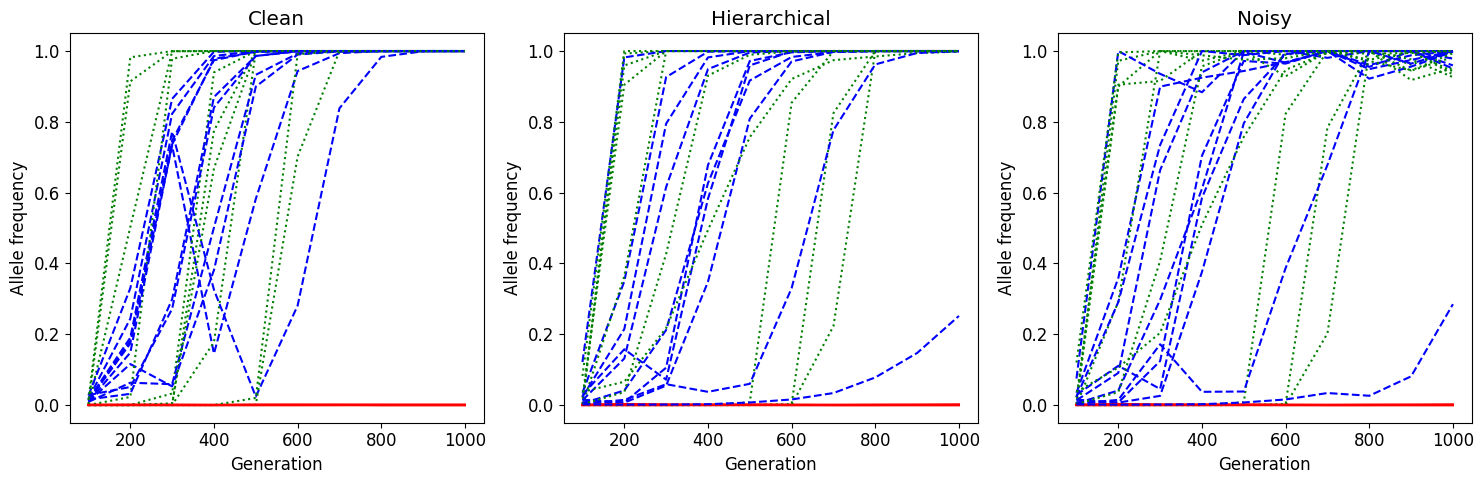

In [6]:
# plot x_test, x_test_h, x_test_r at pos 0
# obs is 10,30
# use 3 axes
change_font(12)
from evo_sim import plot_vec30

x_test = torch.load('x_test.pt')
x_test_h = torch.load('x_test_h.pt')
x_test_r = torch.load('x_test_r.pt')

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

t = 5
for i in range(10):
    plot_vec30(ax=ax[0], vec30=x_test[t, i], title="Clean")
    plot_vec30(ax=ax[1], vec30=x_test_h[t, i], title="Hierarchical")
    plot_vec30(ax=ax[2], vec30=x_test_r[t, i], title="Noisy")

Evaluating 100000 samples: 100%|██████████| 10/10 [00:01<00:00,  8.47it/s]


Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

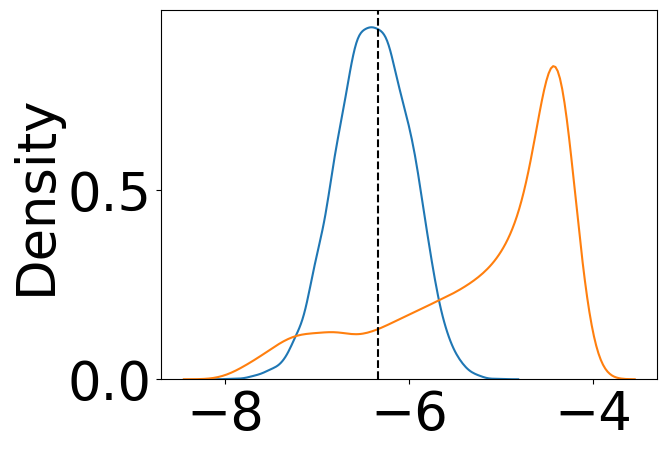

In [33]:
from seaborn import histplot
j = 106
theta_test = torch.load("theta_test.pt")[j]
x_test = torch.load("x_test.pt")[j]
op = CollectivePosterior(prior, x_test, posterior, 1, epsilon=-10, n_eval=100000)
samples_imp = op.sample_via_sir_jitter(excess_quantile=0.5)

posterior_iid = pickle.load(open("posterior_iid.pkl", "rb"))
samples_iid = posterior_iid.set_default_x(x_test).sample((10_000,))
# op.get_log_C()
# samples_mcmc = op.sample(1000)

p = 3

kdeplot(samples_imp[:,p])
kdeplot(samples_iid[:,p])
# histplot(samples[:,p], stat="density", linewidth=0, bins=100, color='tomato')
# histplot(samples_imp[:,p], stat="density", linewidth=0, bins=100, color='blue')
# kdeplot(samples[:,p], color='tomato')
# kdeplot(samples_mcmc[:,p])
plt.axvline(theta_test[p].item(), color='k', ls='--')